# Augmented Reality Virtual Try-on Survey Data Analysis

In [2]:
#print(sklearn.__version__)

In [3]:
#!pip freeze > requirements.txt

In [ ]:
1.  Dissertation - AR VTO-Latest Version 09172024 Cleaned Dataset-Copy1
2.  Dissertation - AR VTO-Latest Version 09172024-Data Exploration-Copy1
3.  Dissertation - AR VTO-Latest Version 09172024- Create PCA Feature List
4.  Dissertation - AR VTO-Latest Version 09172024-BuildTestHarnesses-with extra models
##5.  Dissertation - AR VTO-Latest Version TAM
6.  Dissertation - AR VTO-Latest Version Gradient Boost
7.  Dissertation - AR VTO-Latest Version KNN 
8.  Dissertation - AR VTO-Latest Version Lasso
9.  Dissertation - AR VTO-Latest Version MLP
10. Dissertation - AR VTO-Latest Version MLR
11. Dissertation - AR VTO-Latest Version RF
12. Dissertation - AR VTO-Latest Version Ridge
13. Dissertation - AR VTO-Latest Version SVR
13. Dissertation - AR VTO-Latest Version XGBoost
14. Dissertation - AR VTO - Stats Model MLR
15. Dissertation - AR VTO-Latest Version Final Model

In [38]:
import pandas as pd
import numpy as np
from numpy import arange
import scipy.stats as stats
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score
# Load libraries
import numpy
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv

from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import semopy
from semopy import Model, Optimizer, calc_stats
#from pdpbox import pdp, get_dataset, info_plots
from sklearn.metrics import mutual_info_score
from sklearn import metrics
#import eli5
#from eli5.sklearn import PermutationImportance

# Statistical Analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from factor_analyzer import FactorAnalyzer
import semopy
from semopy import Model, Optimizer, calc_stats

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
 

# Miscellaneous
# Set display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [39]:
#read csv file

df_survey_cleaned = pd.read_csv(r'C:\Users\cemcd\OneDrive\Documents\NCU\Dissertation\DisserationDataFilesInfo\df_suvey_cleaned.csv')

In [40]:
#display column headers and the first row

df_survey_cleaned.head(2)

,Unnamed: 0,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,PE2,PE3,PE4,SOI1,SOI2,SOI3,SOI4,SEI1,SEI2,SEI3,PEOU1,PEOU2,PEOU3,PU1,PU2,PU3,PU4,B1,AT1,AT2,AT3,PPV1,PPV2,PPV3,HM1,HM2,HM3,BI1,BI2,BI3,BI4,Gender,AGE,Location,Gender_eng,Gender_vietnamese,Gender_num,AGE_eng,AGE_num,Age_vietnamese,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7,Usage_1_en,Usage_2_en,Usage_3_en,Usage_4_en,Usage_5_en,Usage_6_en,Usage_7_en,use_type_cnts,BI,PE,SOI,SEI,HM,AT,PPV,PU,PEOU,PE_centered,SOI_centered,SEI_centered,HM_centered,AT_centered,PPV_centered,PU_centered,PEOU_centered,AR_Knowledgeable_centered,familiar_with_technology_centered,use_AR_everyday_centered,Virtual_shopping_environment_centered,Virtual_tour_centered,Visualize_model_centered,Emulation_centered,AGEGender_centered,AGEAR_Knowledgeable,AGEfamiliar_with_technology,AGEuse_AR_everyday,AGEVirtual_shopping_environment,AGEVirtual_tour,AGEVisualize_model,AGEEmulation,GenderAR_Knowledgeable,Genderfamiliar_with_technology,Genderuse_AR_everyday,GenderVirtual_shopping_environment,GenderVirtual_tour,GenderVisualize_model,GenderEmulation,GenderPU_centered,GenderPE_centered,GenderPEOU_centered,GenderAT_centered,GenderPPV_centered,GenderHM_centered,GenderSOI_centered,GenderSEI_centered,AGEPEOU_centered,AGEPU_centered,AGESOI_centered,AGESEI_centered,AGEPPV_centered,AGEHM_centered,AGEPE_centered,AGEAT_centered,PEAT_centered,HMAT_centered,HMPU_centered,HMPEOU_centered,HMSOI_centered,HMSEI_centered,HMPE_centered,HMPPV_centered,SOIPU_centered,SEIPU_centered,SOIPEOU_centered,SEIPEOU_centered,target_variable_num,target_variable_cat,PE_centered_squared,PE_centered_cubed,SOI_centered_squared,SOI_centered_cubed,SEI_centered_squared,SEI_centered_cubed,HM_centered_squared,HM_centered_cubed,AT_centered_squared,AT_centered_cubed,PPV_centered_squared,PPV_centered_cubed,PU_centered_squared,PU_centered_cubed,PEOU_centered_squared,PEOU_centered_cubed,AGEGender_centered_squared,AGEGender_centered_cubed,GenderPU_centered_squared,GenderPU_centered_cubed,GenderPEOU_centered_squared,GenderPEOU_centered_cubed,GenderAT_centered_squared,GenderAT_centered_cubed,GenderPPV_centered_squared,GenderPPV_centered_cubed,GenderPE_centered_squared,GenderPE_centered_cubed,GenderHM_centered_squared,GenderHM_centered_cubed,GenderSOI_centered_squared,GenderSOI_centered_cubed,GenderSEI_centered_squared,GenderSEI_centered_cubed,AGEPEOU_centered_squared,AGEPEOU_centered_cubed,AGEPU_centered_squared,AGEPU_centered_cubed,AGESOI_centered_squared,AGESOI_centered_cubed,AGESEI_centered_squared,AGESEI_centered_cubed,AGEPPV_centered_squared,AGEPPV_centered_cubed,AGEHM_centered_squared,AGEHM_centered_cubed,AGEPE_centered_squared,AGEPE_centered_cubed,AGEAT_centered_squared,AGEAT_centered_cubed,PEAT_centered_squared,PEAT_centered_cubed,HMAT_centered_squared,HMAT_centered_cubed,HMPU_centered_squared,HMPU_centered_cubed,HMPEOU_centered_squared,HMPEOU_centered_cubed,HMSOI_centered_squared,HMSOI_centered_cubed,HMSEI_centered_squared,HMSEI_centered_cubed,HMPE_centered_squared,HMPE_centered_cubed
0,0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old,3,Trên 40 tuổi,Du lịch ảo,trải nghiệm,NaN,NaN,NaN,NaN,NaN,Du lịch ảo,experience,NaN,NaN,NaN,NaN,NaN,2,3.75,4.0,3.0,3.0,4.0,3.666667,4.0,3.25,4.0,0.205189,-0.714033,-0.72327,0.130503,-0.166667,0.211478,-0.568396,0.304245,1.025943,0.016509,0.325472,0.134434,0.233491,0.108491,0.228774,0,3.077830,0.049528,0.976415,0.403302,0.700472,0.325472,0.686321,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,-0.00000,0.912736,-1.705189,-2.142099,-2.169811,0.634434,0.391509,0.615566,-0.500000,-0.034198,-0.021751,-0.074177,0.039705,

In [41]:
#Get Size of dataset
df_survey_cleaned.shape



(424, 199)

# TAM

## Validity

### Harman's Test 

In [42]:
import pandas as pd
from factor_analyzer import FactorAnalyzer


variables = ['PU', 'PEOU', 'PE', 'HM', 'AT', 'SOI', 'SEI', 'Gender_num', 'AGE_num']
df = df_survey_cleaned[variables]

# Drop missing values if any
df.dropna(inplace=True)

# Initialize factor analysis object and perform factor analysis using 1 factor
fa = FactorAnalyzer(n_factors=1, rotation=None)
fa.fit(df)

# Get the variance of each variable explained by the single factor
variances = fa.get_factor_variance()

# The total variance explained by the single factor
total_variance_explained = variances[1][0] * 100

print(f"Total variance explained by the single factor: {total_variance_explained:.2f}%")

# Check for common method bias
if total_variance_explained > 50:
    print("Common method bias is present, as more than 50% of the variance is explained by a single factor.")
else:
    print("Common method bias is not detected, as less than 50% of the variance is explained by a single factor.")

Total variance explained by the single factor: 59.33%
Common method bias is present, as more than 50% of the variance is explained by a single factor.


C:\Users\cemcd\AppData\Local\Temp\ipykernel_7784\3797877342.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


### VIF - to tesst for Multicollinearity amonst the constructs and within the construcst

In [43]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define the variables for VIF analysis
variables_for_vif = [
    "BI1", "BI2", "BI3", "PU1", "PU2", "PU3", "PU4",
    "PEOU1", "PEOU2", "PEOU3",
    "PE1", "PE2", "PE3",
    "PPV1", "PPV2", "PPV3",
    "SEI1", "SEI2", "SEI3",
    "SOI1", "SOI2", "SOI3", "SOI4",
    "AT1", "AT2", "AT3",
    "HM1", "HM2", "HM3"
]

# Select the relevant subset of the DataFrame for VIF analysis
df_vif = df_survey_cleaned[variables_for_vif].copy()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = variables_for_vif
vif_data['VIF'] = [variance_inflation_factor(df_vif.values, i) for i in range(len(variables_for_vif))]

# Sort the dataframe by VIF values in descending order
vif_data = vif_data.sort_values('VIF', ascending=False)

# Display the VIF values
print(vif_data)

# Identify variables with high VIF (e.g., VIF > 5 or 10)
high_vif = vif_data[vif_data['VIF'] > 5]
print("\nVariables with high VIF (> 5):")
print(high_vif)

   Feature        VIF
26     HM1  71.646110
23     AT1  69.192631
4      PU2  68.327793
0      BI1  63.769230
13    PPV1  61.460294
27     HM2  56.321308
16    SEI1  55.884632
28     HM3  55.656466
25     AT3  55.622873
19    SOI1  55.582008
15    PPV3  54.608754
6      PU4  53.805170
3      PU1  52.515605
12     PE3  50.835203
1      BI2  49.851848
5      PU3  49.833931
2      BI3  49.202959
10     PE1  48.384749
24     AT2  47.192898
14    PPV2  46.168397
20    SOI2  45.766473
7    PEOU1  45.602201
8    PEOU2  45.174440
11     PE2  43.733384
21    SOI3  43.484314
9    PEOU3  43.354923
17    SEI2  42.398085
18    SEI3  40.858651
22    SOI4  35.347957

Variables with high VIF (> 5):
   Feature        VIF
26     HM1  71.646110
23     AT1  69.192631
4      PU2  68.327793
0      BI1  63.769230
13    PPV1  61.460294
27     HM2  56.321308
16    SEI1  55.884632
28     HM3  55.656466
25     AT3  55.622873
19    SOI1  55.582008
15    PPV3  54.608754
6      PU4  53.805170
3      PU1  52.515605


In [44]:
### Calculate Fornall

In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
from scipy.stats import pearsonr

# Step 1: Load and prepare your data
# Replace 'your_data.csv' with the path to your actual data file
df = df_survey_cleaned

# List of variables for each construct
constructs = {
    'BI': ['BI1', 'BI2', 'BI3'],
    'PU': ['PU1', 'PU2', 'PU3', 'PU4'],
    'PEOU': ['PEOU1', 'PEOU2', 'PEOU3'],
    'PE': ['PE1', 'PE2', 'PE3'],
    'PPV': ['PPV1', 'PPV2', 'PPV3'],
    'SEI': ['SEI1', 'SEI2', 'SEI3'],
    'SOI': ['SOI1', 'SOI2', 'SOI3', 'SOI4'],
    'AT': ['AT1', 'AT2', 'AT3'],
    'HM': ['HM1', 'HM2', 'HM3']
}

# Standardize the data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[sum(constructs.values(), [])]), 
                         columns=sum(constructs.values(), []))

# Step 2: Calculate factor loadings and AVE for each construct
factor_loadings = {}
ave_values = {}

for construct, items in constructs.items():
    # Perform factor analysis
    fa = FactorAnalyzer(rotation=None, n_factors=1)
    fa.fit(df_scaled[items])
    
    # Get factor loadings
    loadings = fa.loadings_
    factor_loadings[construct] = loadings.flatten()
    
    # Calculate AVE
    ave = np.mean(loadings**2)
    ave_values[construct] = ave

# Print factor loadings and AVE values
print("Factor Loadings:")
for construct, loadings in factor_loadings.items():
    print(f"{construct}: {loadings}")

print("\nAVE Values:")
for construct, ave in ave_values.items():
    print(f"{construct}: {ave:.4f}")

# Step 3: Calculate correlation matrix
correlation_matrix = pd.DataFrame(index=constructs.keys(), columns=constructs.keys())

for construct1 in constructs:
    for construct2 in constructs:
        if construct1 == construct2:
            correlation_matrix.loc[construct1, construct2] = 1.0
        else:
            # Calculate average correlation between items of the two constructs
            correlations = []
            for item1 in constructs[construct1]:
                for item2 in constructs[construct2]:
                    corr, _ = pearsonr(df_scaled[item1], df_scaled[item2])
                    correlations.append(corr)
            avg_corr = np.mean(correlations)
            correlation_matrix.loc[construct1, construct2] = avg_corr

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Step 4: Perform Fornell-Larcker criterion test
def fornell_larcker_test(correlation_matrix, ave_values):
    results = {}
    for construct in correlation_matrix.columns:
        # Get correlations for this construct
        correlations = correlation_matrix[construct]
        # Get square root of AVE for this construct
        ave_sqrt = np.sqrt(ave_values[construct])
        # Check if square root of AVE is greater than correlations with other constructs
        validity_check = all(ave_sqrt > correlations[correlations.index != construct])
        results[construct] = validity_check
    return results

# Run the test
fl_results = fornell_larcker_test(correlation_matrix, ave_values)

# Print results
print("\nFornell-Larcker Criterion Test Results:")
for construct, result in fl_results.items():
    print(f"{construct}: {'Pass' if result else 'Fail'}")

# Create a comparison matrix
comparison_df = correlation_matrix.copy()
for construct in comparison_df.columns:
    comparison_df.loc[construct, construct] = np.sqrt(ave_values[construct])

print("\nComparison Matrix (diagonal shows sqrt(AVE)):")
print(comparison_df)

Factor Loadings:
BI: [-0.90005427 -0.82274156 -0.82423183]
PU: [-0.81252369 -0.89099994 -0.81656855 -0.84397382]
PEOU: [-0.87073523 -0.81822265 -0.82930762]
PE: [-0.87576949 -0.84082171 -0.87300026]
PPV: [-0.87259342 -0.76441926 -0.80196911]
SEI: [-0.88566677 -0.82131411 -0.81487875]
SOI: [-0.88310338 -0.78389845 -0.84695857 -0.79149459]
AT: [-0.9039535  -0.82934835 -0.80962388]
HM: [0.88600861 0.83941421 0.86726897]

AVE Values:
BI: 0.7221
PU: 0.7083
PEOU: 0.7051
PE: 0.7454
PPV: 0.6630
SEI: 0.7077
SOI: 0.6845
AT: 0.7201
HM: 0.7473

Correlation Matrix:
            BI        PU      PEOU        PE       PPV       SEI       SOI  \
BI         1.0  0.646907  0.599704  0.593918  0.647837  0.610309  0.587627   
PU    0.646907       1.0  0.666165  0.567782  0.632443   0.61223  0.556559   
PEOU  0.599704  0.666165       1.0  0.572704  0.584002  0.609371  0.570682   
PE    0.593918  0.567782  0.572704       1.0  0.561538  0.599773  0.639127   
PPV   0.647837  0.632443  0.584002  0.561538       

### KMO Adequacy

In [46]:
from factor_analyzer.factor_analyzer import calculate_kmo


independent_vars = ['PU1', 'PU2', 'PU3','PU4','AT1', 'AT2', 'AT3', 'PEOU1', 'PEOU2', 'PEOU3',
                   'PPV1', 'PPV2', 'PPV3', 'HM1', 'HM2', 'HM3', 'SOI1', 'SOI2', 'SOI3','SOI4',
                   'SEI1', 'SEI2', 'SEI3', 'PE1', 'PE2', 'PE3','PE4']
dependent_var = 'BI'

# Calculate the KMO test
kmo_all, kmo_model = calculate_kmo(df_survey_cleaned[independent_vars])

# Print the KMO value
print(f"KMO Model Adequacy: {kmo_model:.4f}")

KMO Model Adequacy: 0.9788


C:\Users\cemcd\anaconda3\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [47]:
import pandas as pd
from factor_analyzer.factor_analyzer import calculate_kmo


# Extract the independent variables
independent_vars = ['PU1', 'PU2', 'PU3','PU4','AT1', 'AT2', 'AT3', 'PEOU1', 'PEOU2', 'PEOU3',
                   'PPV1', 'PPV2', 'PPV3', 'HM1', 'HM2', 'HM3', 'SOI1', 'SOI2', 'SOI3','SOI4',
                   'SEI1', 'SEI2', 'SEI3', 'PE1', 'PE2', 'PE3','PE4']
dependent_var = 'BI'

X = df_survey_cleaned[independent_vars]

# Perform the KMO test
kmo_all, kmo_model = calculate_kmo(X)

# Print the overall KMO value
print(f"Overall KMO: {kmo_model:.4f}")

# Print the KMO values for each independent variable
for col in X.columns:
    kmo_value = X[col].corr(X[col])
    print(f"KMO for {col}: {kmo_value:.4f}")

Overall KMO: 0.9788
KMO for PU1: 1.0000
KMO for PU2: 1.0000
KMO for PU3: 1.0000
KMO for PU4: 1.0000
KMO for AT1: 1.0000
KMO for AT2: 1.0000
KMO for AT3: 1.0000
KMO for PEOU1: 1.0000
KMO for PEOU2: 1.0000
KMO for PEOU3: 1.0000
KMO for PPV1: 1.0000
KMO for PPV2: 1.0000
KMO for PPV3: 1.0000
KMO for HM1: 1.0000
KMO for HM2: 1.0000
KMO for HM3: 1.0000
KMO for SOI1: 1.0000
KMO for SOI2: 1.0000
KMO for SOI3: 1.0000
KMO for SOI4: 1.0000
KMO for SEI1: 1.0000
KMO for SEI2: 1.0000
KMO for SEI3: 1.0000
KMO for PE1: 1.0000
KMO for PE2: 1.0000
KMO for PE3: 1.0000
KMO for PE4: 1.0000


C:\Users\cemcd\anaconda3\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [48]:
 
#df = df_survey[variables]

import pandas as pd
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

 
variables = ['PU1', 'PU2', 'PU3','PU4','AT1', 'AT2', 'AT3', 'PEOU1', 'PEOU2', 'PEOU3',
                   'PPV1', 'PPV2', 'PPV3', 'HM1', 'HM2', 'HM3', 'SOI1', 'SOI2', 'SOI3','SOI4',
                   'SEI1', 'SEI2', 'SEI3', 'PE1', 'PE2', 'PE3','PE4']
df = df_survey_cleaned[variables]

# Check the suitability of my data for factor analysis
chi_square_value, p_value = calculate_bartlett_sphericity(df)
kmo_all, kmo_model = calculate_kmo(df)

print(f"Bartlett's test chi-square value: {chi_square_value}, p-value: {p_value}")
print(f"KMO test: {kmo_model}")

# Perform EFA
fa = FactorAnalyzer(rotation=None, n_factors=7, method='minres')
fa.fit(df)

# Check Eigenvalues to decide the number of factors
ev, v = fa.get_eigenvalues()
print(f"Eigenvalues: {ev}")

# You might decide to rotate factors for better interpretability
fa = FactorAnalyzer(rotation='varimax', n_factors=7, method='minres')
fa.fit(df)
loadings = fa.loadings_

# Get the factor loadings
print("Factor Loadings:\n", pd.DataFrame(loadings, index=variables))

# Optionally, get the variance explained by each factor
variance = fa.get_factor_variance()

Bartlett's test chi-square value: 10994.345578956547, p-value: 0.0
KMO test: 0.9787776526552086
Eigenvalues: [17.09730972  1.37650634  0.89192076  0.83768344  0.5409698   0.4995804
  0.42616358  0.41976206  0.38481747  0.38083618  0.35471642  0.34234865
  0.31203775  0.30115581  0.29073825  0.28321718  0.26199068  0.25262612
  0.23086104  0.22067317  0.21185386  0.20762442  0.19726608  0.18960938
  0.17298394  0.16473247  0.15001503]
Factor Loadings:
               0         1         2         3         4         5         6
PU1    0.442858  0.240594  0.266875  0.669239  0.049916  0.006296 -0.022503
PU2    0.554236  0.278165  0.249825  0.500579  0.305477  0.030987 -0.004635
PU3    0.606368  0.284949  0.214562  0.361167  0.267920 -0.026475  0.153691
PU4    0.587258  0.313443  0.200115  0.446573  0.160716  0.006078  0.013547
AT1    0.670408  0.321152  0.217191  0.322971  0.256336  0.123652 -0.081686
AT2    0.657975  0.297298  0.215081  0.274338  0.093904  0.241351 -0.030628
AT3    0.617

C:\Users\cemcd\anaconda3\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


### Cronbach's Alpha

In [49]:
import pandas as pd
from pingouin import cronbach_alpha

# Define constructs
constructs = {
    'PU': ['PU1', 'PU2', 'PU3','PU4'],
    'AT': ['AT1', 'AT2', 'AT3'],
    'PEU': ['PEOU1', 'PEOU2', 'PEOU3'],
    'PPV': ['PPV1', 'PPV2', 'PPV3'],
    'HM': ['HM1', 'HM2', 'HM3'],
    'SOI': ['SOI1', 'SOI2', 'SOI3','SOI4'],
    'SEI': ['SEI1', 'SEI2', 'SEI3'],
    'PE': ['PE1', 'PE2', 'PE3','PE4']
}

# Calculate Cronbach's alpha for each construct
for construct, variables in constructs.items():
    construct_data = df_survey_cleaned[variables]
    alpha = cronbach_alpha(construct_data)
    print(f"Cronbach's alpha for {construct}: {alpha}")

Cronbach's alpha for PU: (0.9054292595424759, array([0.89 , 0.919]))
Cronbach's alpha for AT: (0.8835933597202476, array([0.863, 0.902]))
Cronbach's alpha for PEU: (0.8773070383038567, array([0.856, 0.896]))
Cronbach's alpha for PPV: (0.8526684581044442, array([0.827, 0.875]))
Cronbach's alpha for HM: (0.8978540190527856, array([0.88 , 0.914]))
Cronbach's alpha for SOI: (0.8954501139847528, array([0.878, 0.911]))
Cronbach's alpha for SEI: (0.8775892033766053, array([0.856, 0.896]))
Cronbach's alpha for PE: (0.9240634129575526, array([0.912, 0.935]))


### Exploratory Factor Analysis

In [50]:
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import pingouin as pg


# Extract the independent variables
X = df_survey_cleaned[['PU1', 'PU2', 'PU3','PU4', 'AT1', 'AT2', 'AT3', 'PEOU1', 'PEOU2', 'PEOU3', 'PPV1', 'PPV2', 'PPV3', 
               'HM1', 'HM2', 'HM3', 'SOI1', 'SOI2', 'SOI3','SOI4', 'SEI1', 'SEI2', 'SEI3', 'PE1', 'PE2', 'PE3','PE4']]

# Perform EFA
fa = FactorAnalyzer(n_factors=3, rotation="varimax")
fa.fit(X)
loadings = fa.loadings_

# Calculate Cronbach's alpha for each factor
print("Reliability Analysis:")
for i in range(3):
    factor_items = [X.columns[j] for j, loading in enumerate(loadings[:, i]) if abs(loading) > 0.4]
    factor_data = X[factor_items]
    alpha_value = pg.cronbach_alpha(factor_data)
    print(f"Factor {i+1} Cronbach's Alpha:", alpha_value)

Reliability Analysis:
Factor 1 Cronbach's Alpha: (0.965986098565747, array([0.961, 0.971]))
Factor 2 Cronbach's Alpha: (0.9624211805149268, array([0.957, 0.967]))
Factor 3 Cronbach's Alpha: (0.9411595844133621, array([0.932, 0.949]))


### Construct Validity -  Convergent and Discriminant Validity

In [51]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
from scipy.stats import pearsonr


# Extract the independent variables
X = df_survey_cleaned [['PU1', 'PU2', 'PU3','PU4','AT1', 'AT2', 'AT3', 'PEOU1', 'PEOU2', 'PEOU3','PPV1',
                        'PPV2', 'PPV3', 'HM1', 'HM2', 'HM3', 'SOI1', 'SOI2', 'SOI3', 'SEI1', 'SEI2', 'SEI3', 'PE1', 'PE2', 'PE3','PE4']]

# Perform exploratory factor analysis
fa = FactorAnalyzer(n_factors=7, rotation="varimax")
fa.fit(X)
loadings = fa.loadings_

# Calculate factor scores
factor_scores = fa.transform(X)

# Assess convergent validity
print("Convergent Validity:")
for i in range(7):
    factor_name = f"Factor {i+1}"
    print(f"{factor_name}:")
    for j, variable in enumerate(X.columns):
        corr, p_value = pearsonr(factor_scores[:, i], X[variable])
        print(f"{variable}: r = {corr:.4f}, p = {p_value:.4f}")
    print()

# Assess discriminant validity
print("Discriminant Validity:")
for i in range(7):
    factor_name = f"Factor {i+1}"
    print(f"{factor_name}:")
    for j in range(7):
        if i != j:
            other_factor_name = f"Factor {j+1}"
            corr, p_value = pearsonr(factor_scores[:, i], factor_scores[:, j])
            print(f"{factor_name} vs {other_factor_name}: r = {corr:.4f}, p = {p_value:.4f}")
    print()

Convergent Validity:
Factor 1:
PU1: r = 0.4451, p = 0.0000
PU2: r = 0.5358, p = 0.0000
PU3: r = 0.6046, p = 0.0000
PU4: r = 0.5974, p = 0.0000
AT1: r = 0.6734, p = 0.0000
AT2: r = 0.6611, p = 0.0000
AT3: r = 0.6326, p = 0.0000
PEOU1: r = 0.3299, p = 0.0000
PEOU2: r = 0.4003, p = 0.0000
PEOU3: r = 0.3512, p = 0.0000
PPV1: r = 0.6433, p = 0.0000
PPV2: r = 0.5960, p = 0.0000
PPV3: r = 0.7182, p = 0.0000
HM1: r = 0.7937, p = 0.0000
HM2: r = 0.7824, p = 0.0000
HM3: r = 0.7595, p = 0.0000
SOI1: r = 0.3272, p = 0.0000
SOI2: r = 0.4135, p = 0.0000
SOI3: r = 0.3810, p = 0.0000
SEI1: r = 0.3883, p = 0.0000
SEI2: r = 0.3480, p = 0.0000
SEI3: r = 0.4008, p = 0.0000
PE1: r = 0.3151, p = 0.0000
PE2: r = 0.3329, p = 0.0000
PE3: r = 0.3355, p = 0.0000
PE4: r = 0.3542, p = 0.0000

Factor 2:
PU1: r = 0.2890, p = 0.0000
PU2: r = 0.3207, p = 0.0000
PU3: r = 0.3159, p = 0.0000
PU4: r = 0.3545, p = 0.0000
AT1: r = 0.3635, p = 0.0000
AT2: r = 0.3312, p = 0.0000
AT3: r = 0.3518, p = 0.0000
PEOU1: r = 0.3799, 

In [52]:
# Set pandas display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Confirmatory Factory Analysis (CFA)

In [53]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

X = df_survey_cleaned

# Create a StandardScaler object
scaler = StandardScaler()

# List of variables to standardize (exclude the target variable if you have one)
variables_to_standardize = [
    "BI1", "BI2", "BI3", "PU1", "PU2", "PU3", "PU4", 
    "PEOU1", "PEOU2", "PEOU3", "PE1", "PE2", "PE3", 
    "PPV1", "PPV2", "PPV3", "SEI1", "SEI2", "SEI3", 
    "SOI1", "SOI2", "SOI3", "SOI4", "AT1", "AT2", "AT3", 
    "HM1", "HM2", "HM3", "AGE_num", "Gender_num"
]

# Standardize the selected variables
X_standardized = X.copy()
X_standardized[variables_to_standardize] = scaler.fit_transform(X[variables_to_standardize])

# Print the first few rows of the standardized data to verify
#print(X_standardized.head())

# check the mean and standard deviation of the standardized variables
#print("\nMean of standardized variables:")
#print(X_standardized[variables_to_standardize].mean())
#print("\nStandard deviation of standardized variables:")
#print(X_standardized[variables_to_standardize].std())

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from semopy import Model
from semopy.stats import calc_stats

# Step 1: Data Preparation
scaler = StandardScaler()

variables_to_standardize = [
    "BI1", "BI2", "BI3", "PU1", "PU2", "PU3", "PU4", 
    "PEOU1", "PEOU2", "PEOU3", 
    "PE1", "PE2", "PE3", 
    "PPV1", "PPV2", "PPV3",
    "SEI1", "SEI2", "SEI3", 
    "SOI1", "SOI2", "SOI3", "SOI4",
    "AT1", "AT2", "AT3", 
    "HM1", "HM2", "HM3", "AGE_num", "Gender_num"
]
X = df_survey_cleaned[variables_to_standardize]

# Standardize the selected variables
X_standardized = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Step 2: Define the model
model = """
    # Measurement model
    BI =~ BI1 + BI2 + BI3
    PU =~ PU1 + PU2 + PU3 + PU4
    PEOU =~ PEOU1 + PEOU2 + PEOU3
    PE =~ PE1 + PE2 + PE3
    PPV =~ PPV1 + PPV2 + PPV3
    SEI =~ SEI1 + SEI2 + SEI3
    SOI =~ SOI1 + SOI2 + SOI3 + SOI4
    AT =~ AT1 + AT2 + AT3
    HM =~ HM1 + HM2 + HM3
    AGE =~ AGE_num
    GENDER =~ Gender_num
"""

# Step 3: Fit the model
sem_model = Model(model)
results = sem_model.fit(X_standardized)

# Step 4: Calculate and print fit indices
stats = calc_stats(sem_model)

stats

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,379,465,738.100796,0.0,12364.918377,0.969823,0.940307,0.926762,0.940307,0.962976,0.047328,230.518392,704.337207,1.740804


## Create TAM Model 

### TAM model using all constructs except PE - be sure to mention Davis, VAn heyden

In [55]:
pd.set_option('display.max_rows', 500)

Total variance of BI: 0.35015622209197006
Path Coefficients related to BI:
   lval op  rval  Estimate  Std. Err   z-value   p-value
12   BI  ~    PU  0.350156  0.065121  5.377019       0.0
13   BI  ~  PEOU  0.154480  0.088112  1.753227  0.079563
14   BI  ~    HM  0.506552  0.073022  6.936964       0.0

Model Fit Statistics:
       DoF  DoF Baseline        chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  333           380  836.203144           0.0   10931.416846  0.952309   

            GFI      AGFI       NFI       TLI     RMSEA         AIC  \
Value  0.923505  0.912708  0.923505  0.945578  0.059769  142.055646   

              BIC    LogLik  
Value  437.686188  1.972177  

TAM_model_BI_R_squared:
  model_name  BI_R_squared run_type
0        TAM      0.952939  Initial

TAM_BI_important_features:
   from  to  Estimate   Std_Err   z-value       p-value  rank
0    HM  BI  0.506552  0.073022  6.936964  4.006129e-12   1.0
1    PU  BI  0.350156  0.065121  5.377019  7.572933e-08   2.0
2

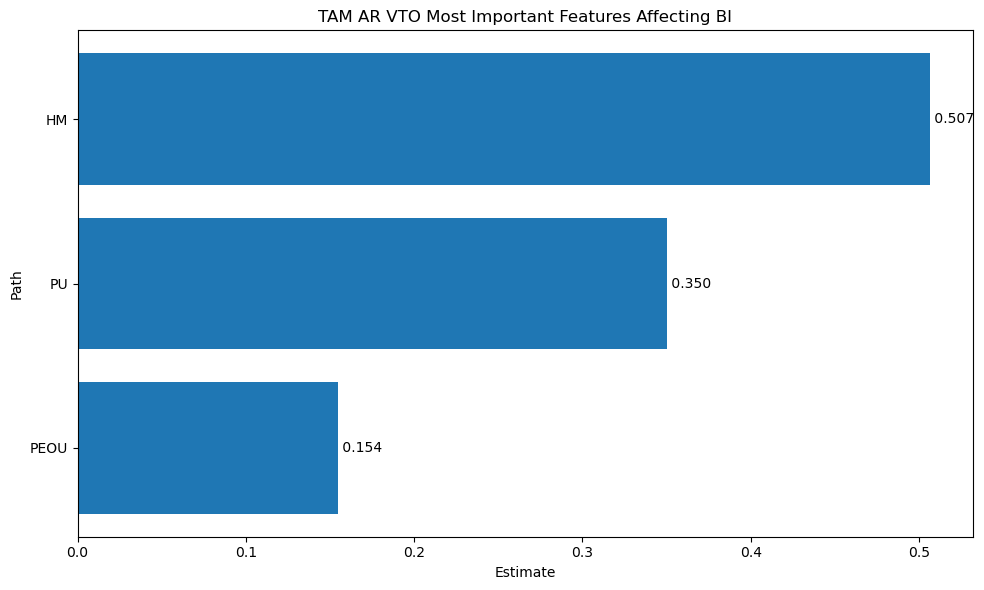

In [62]:
import pandas as pd
import numpy as np
from semopy import Model, calc_stats
import matplotlib.pyplot as plt

# Define the model specification
model_spec = """
# Measurement model
PU =~ PU1 + PU2 + PU3 + PU4
PEOU =~ PE1 + PE2 + PE3
BI =~ BI1 + BI2 + BI3
PPV =~PPV1 + PPV2 + PPV3
SOI =~ SOI1+ SOI2 +SOI3 + SOI4
SEI =~ SEI1 + SEI2 + SEI3
HM =~ HM1 +HM2 + HM3
AT =~ AT1 + AT2 + AT3

# Structural model
PEOU ~  PPV + SOI + SEI + AGE_num + Gender_num
PU ~ HM + PPV + SOI + SEI + AGE_num + Gender_num
HM ~ PEOU
BI ~ PU 
BI ~ PEOU
BI ~ HM
"""

# Create and fit the model
model = Model(model_spec)
res = model.fit(df_survey_cleaned)

# Get the parameter estimates
estimates = model.inspect()

# Find the variance of BI
bi_variance = estimates[estimates['lval'] == 'BI']['Estimate'].values[0]
print(f"Total variance of BI: {bi_variance}")

# Extract only path coefficients related to BI
bi_paths = estimates[(estimates['lval'] == 'BI') & (estimates['op'] == '~')]

print("Path Coefficients related to BI:")
print(bi_paths)

# Calculate and print fit statistics
fit_stats = calc_stats(model)
print("\nModel Fit Statistics:")
print(fit_stats)

# R-squared values for endogenous variables
r_squared = estimates[estimates['op'] == '~~'].copy()
r_squared['R_squared'] = 1 - pd.to_numeric(r_squared['Estimate'], errors='coerce')
r_squared = r_squared[r_squared['lval'] == r_squared['rval']]  # Only keep diagonal elements
r_squared = r_squared[['lval', 'R_squared']]
r_squared.columns = ['Variable', 'R_squared']

# Find the R-squared of BI
bi_r_squared = r_squared[r_squared['Variable'] == 'BI']['R_squared'].values

if len(bi_r_squared) > 0:
    bi_r_squared = bi_r_squared[0]
    # Create TAM_model_BI_R_squared dataframe
    TAM_model_BI_R_squared = pd.DataFrame({
        'model_name': ['TAM'],
        'BI_R_squared': [bi_r_squared],
        'run_type': ['Initial']
    })
    print("\nTAM_model_BI_R_squared:")
    print(TAM_model_BI_R_squared)
else:
    print("\nWarning: R-squared for BI not found in the DataFrame.")

# Create a list to store the important features
important_features = []

for _, row in bi_paths.iterrows():
    feature = {
        'from': row['rval'],
        'to': row['lval'],
        'Estimate': row['Estimate'],
        'Std_Err': row['Std. Err'],
        'z-value': row['z-value'],
        'p-value': row['p-value']
    }
    important_features.append(feature)

# Create TAM_BI_important_features dataframe
TAM_BI_important_features = pd.DataFrame(important_features)

# Add rank column based on absolute Estimate value
TAM_BI_important_features['rank'] = TAM_BI_important_features['Estimate'].abs().rank(ascending=False, method='dense')

# Sort by rank
TAM_BI_important_features = TAM_BI_important_features.sort_values('rank')

# Reset index
TAM_BI_important_features = TAM_BI_important_features.reset_index(drop=True)

# Print the results
print("\nTAM_BI_important_features:")
print(TAM_BI_important_features)

# Effect Sizes (Standardized Estimates) for BI paths
print("\nEffect Sizes (Standardized Estimates) for BI paths:")
standardized_estimates = bi_paths.copy()
standardized_estimates['Estimate'] = pd.to_numeric(standardized_estimates['Estimate'], errors='coerce')
standardized_estimates['Std_Err'] = pd.to_numeric(standardized_estimates['Std. Err'], errors='coerce')
standardized_estimates['Std_Estimate'] = standardized_estimates['Estimate'] / standardized_estimates['Std_Err']
standardized_estimates['Std_Estimate'] = standardized_estimates['Std_Estimate'].replace([np.inf, -np.inf], np.nan)
print(standardized_estimates[['lval', 'rval', 'Std_Estimate']])

# Plotting the most important features
plt.figure(figsize=(10, 6))
plt.barh(TAM_BI_important_features['from'], TAM_BI_important_features['Estimate'])
plt.xlabel('Estimate')
plt.ylabel('Path')
plt.title('TAM AR VTO Most Important Features Affecting BI')
plt.gca().invert_yaxis()  # Invert y-axis to show highest estimate at the top
for i, v in enumerate(TAM_BI_important_features['Estimate']):
    plt.text(v, i, f' {v:.3f}', va='center')
plt.tight_layout()
plt.show()

In [57]:
stats

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,379,465,738.100796,0.0,12364.918377,0.969823,0.940307,0.926762,0.940307,0.962976,0.047328,230.518392,704.337207,1.740804


In [64]:
import pandas as pd
import numpy as np
from semopy import Model, calc_stats
import matplotlib.pyplot as plt

# Define the model specification
model_spec = """
# Measurement model
PU =~ PU1 + PU2 + PU3 + PU4
PEOU =~ PE1 + PE2 + PE3
BI =~ BI1 + BI2 + BI3
PPV =~PPV1 + PPV2 + PPV3
SOI =~ SOI1+ SOI2 +SOI3 + SOI4
SEI =~ SEI1 + SEI2 + SEI3
HM =~ HM1 +HM2 + HM3
AT =~ AT1 + AT2 + AT3

# Structural model
PEOU ~  PPV + SOI + SEI + AGE_num + Gender_num
PU ~ HM + PPV + SOI + SEI + AGE_num + Gender_num
HM ~ PEOU
BI ~ PU + PEOU + HM
"""

# Create and fit the model
model = Model(model_spec)
res = model.fit(df_survey_cleaned)

# Get the parameter estimates
estimates = model.inspect()

# Extract only path coefficients related to BI, PU, and PEOU
relevant_paths = estimates[
    (estimates['op'] == '~') & 
    (estimates['lval'].isin(['BI', 'PU', 'PEOU']))
]

print("Path Coefficients related to BI, PU, and PEOU:")
print(relevant_paths)

# Calculate and print fit statistics
fit_stats = calc_stats(model)
print("\nModel Fit Statistics:")
print(fit_stats)

# R-squared values for endogenous variables
r_squared = estimates[estimates['op'] == '~~'].copy()
r_squared['R_squared'] = 1 - pd.to_numeric(r_squared['Estimate'], errors='coerce')
r_squared = r_squared[r_squared['lval'] == r_squared['rval']]  # Only keep diagonal elements
r_squared = r_squared[['lval', 'R_squared']]
r_squared.columns = ['Variable', 'R_squared']

# Find the R-squared of BI, PU, and PEOU
important_r_squared = r_squared[r_squared['Variable'].isin(['BI', 'PU', 'PEOU'])]

print("\nR-squared values for BI, PU, and PEOU:")
print(important_r_squared)

# Create a list to store the important features
important_features = []

for _, row in relevant_paths.iterrows():
    feature = {
        'from': row['rval'],
        'to': row['lval'],
        'Estimate': row['Estimate'],
        'Std_Err': row['Std. Err'],
        'z-value': row['z-value'],
        'p-value': row['p-value']
    }
    important_features.append(feature)

# Create TAM_important_features dataframe
TAM_important_features = pd.DataFrame(important_features)

# Add rank column based on absolute Estimate value
TAM_important_features['rank'] = TAM_important_features.groupby('to')['Estimate'].abs().rank(ascending=False, method='dense')

# Sort by 'to' and then by rank
TAM_important_features = TAM_important_features.sort_values(['to', 'rank'])

# Reset index
TAM_important_features = TAM_important_features.reset_index(drop=True)

# Print the results
print("\nTAM_important_features:")
print(TAM_important_features)

# Create a list to store the important features
important_features = []

for path in paths:
    coef = estimates[(estimates['lval'] == path[0]) & 
                     (estimates['op'] == '~') & 
                     (estimates['rval'] == path[1])]
    if not coef.empty:
        feature = {
            'from': path[1],
            'to': path[0],
            'Estimate': coef['Estimate'].values[0],
            'Std_Err': coef['Std. Err'].values[0],
            'z-value': coef['z-value'].values[0],
            'p-value': coef['p-value'].values[0]
        }
        important_features.append(feature)

# Create TAM_important_features dataframe
TAM_important_features = pd.DataFrame(important_features)

# Convert 'Estimate' to numeric type
TAM_important_features['Estimate'] = pd.to_numeric(TAM_important_features['Estimate'], errors='coerce')

# Add rank column based on absolute Estimate value
TAM_important_features['rank'] = TAM_important_features.groupby('to')['Estimate'].transform(lambda x: x.abs().rank(ascending=False, method='dense'))

# Sort by 'to' and then by rank
TAM_important_features = TAM_important_features.sort_values(['to', 'rank'])

# Reset index
TAM_important_features = TAM_important_features.reset_index(drop=True)

# Print the results
print("TAM_important_features:")
print(TAM_important_features)

# Effect Sizes (Standardized Estimates)
print("\nEffect Sizes (Standardized Estimates):")
standardized_estimates = relevant_paths.copy()
standardized_estimates['Estimate'] = pd.to_numeric(standardized_estimates['Estimate'], errors='coerce')
standardized_estimates['Std_Err'] = pd.to_numeric(standardized_estimates['Std. Err'], errors='coerce')
standardized_estimates['Std_Estimate'] = standardized_estimates['Estimate'] / standardized_estimates['Std_Err']
standardized_estimates['Std_Estimate'] = standardized_estimates['Std_Estimate'].replace([np.inf, -np.inf], np.nan)
print(standardized_estimates[['lval', 'rval', 'Std_Estimate']])

# Plotting the most important features
plt.figure(figsize=(12, 8))
for target in ['BI', 'PU', 'PEOU']:
    target_data = TAM_important_features[TAM_important_features['to'] == target]
    plt.subplot(1, 3, ['BI', 'PU', 'PEOU'].index(target) + 1)
    plt.barh(target_data['from'], target_data['Estimate'])
    plt.xlabel('Estimate')
    plt.ylabel('Predictor')
    plt.title(f'Factors Affecting {target}')
    plt.gca().invert_yaxis()  # Invert y-axis to show highest estimate at the top
    for i, v in enumerate(target_data['Estimate']):
        plt.text(v, i, f' {v:.3f}', va='center')
plt.tight_layout()
plt.show()

# Extract coefficients for age and gender effects on PU and PEOU
age_gender_effects = estimates[
    (estimates['op'] == '~') & 
    (estimates['lval'].isin(['PU', 'PEOU'])) & 
    (estimates['rval'].isin(['AGE_num', 'Gender_num']))
]

print("\nEffects of Age and Gender on PU and PEOU:")
print(age_gender_effects)

# Calculate standardized estimates for these effects
age_gender_std_effects = age_gender_effects.copy()
age_gender_std_effects['Estimate'] = pd.to_numeric(age_gender_std_effects['Estimate'], errors='coerce')
age_gender_std_effects['Std_Err'] = pd.to_numeric(age_gender_std_effects['Std. Err'], errors='coerce')
age_gender_std_effects['Std_Estimate'] = age_gender_std_effects['Estimate'] / age_gender_std_effects['Std_Err']
age_gender_std_effects['Std_Estimate'] = age_gender_std_effects['Std_Estimate'].replace([np.inf, -np.inf], np.nan)

print("\nStandardized Effects of Age and Gender on PU and PEOU:")
print(age_gender_std_effects[['lval', 'rval', 'Std_Estimate']])

Path Coefficients related to BI, PU, and PEOU:
    lval op        rval  Estimate  Std. Err   z-value   p-value
0   PEOU  ~         PPV  0.727382  0.118025  6.162961       0.0
1   PEOU  ~         SOI  0.836403  0.169182  4.943808  0.000001
2   PEOU  ~         SEI -0.509360  0.210511  -2.41963  0.015536
3   PEOU  ~     AGE_num  0.002353  0.023221  0.101311  0.919304
4   PEOU  ~  Gender_num -0.070924  0.045888 -1.545588  0.122204
5     PU  ~          HM  0.189113  0.063345  2.985443  0.002832
6     PU  ~         PPV  1.055547  0.127765  8.261635       0.0
7     PU  ~         SOI -0.345556  0.159828 -2.162057  0.030614
8     PU  ~         SEI  0.212233  0.182489  1.162988  0.244834
9     PU  ~     AGE_num -0.048226  0.022773 -2.117694  0.034201
10    PU  ~  Gender_num  0.077363   0.04508  1.716129  0.086138
12    BI  ~          PU  0.350156  0.065121  5.377019       0.0
13    BI  ~        PEOU  0.154480  0.088112  1.753227  0.079563
14    BI  ~          HM  0.506552  0.073022  6.936964    

AttributeError: 'SeriesGroupBy' object has no attribute 'abs'

estimates:     lval  op                 rval  Estimate  Std. Err    z-value   p-value
0   PEOU   ~                  PPV  0.722020  0.118557   6.090062       0.0
1   PEOU   ~                  SOI  0.843640  0.169277   4.983775  0.000001
2   PEOU   ~                  SEI -0.511859  0.210576  -2.430749  0.015068
3   PEOU   ~              AGE_num  0.003205  0.023442   0.136724  0.891249
4   PEOU   ~           Gender_num -0.072512  0.046315  -1.565644  0.117432
5     PU   ~                   HM  0.197730  0.062499   3.163745  0.001558
6     PU   ~                  PPV  1.051326   0.12659   8.304968       0.0
7     PU   ~                  SOI -0.342850  0.157973  -2.170314  0.029983
8     PU   ~                  SEI  0.205864  0.180059    1.14331   0.25291
9     PU   ~              AGE_num -0.049159  0.022535  -2.181492  0.029147
10    PU   ~           Gender_num  0.074751  0.044596   1.676167  0.093705
11    HM   ~                 PEOU  0.867872  0.046015  18.860527       0.0
12    BI   ~  

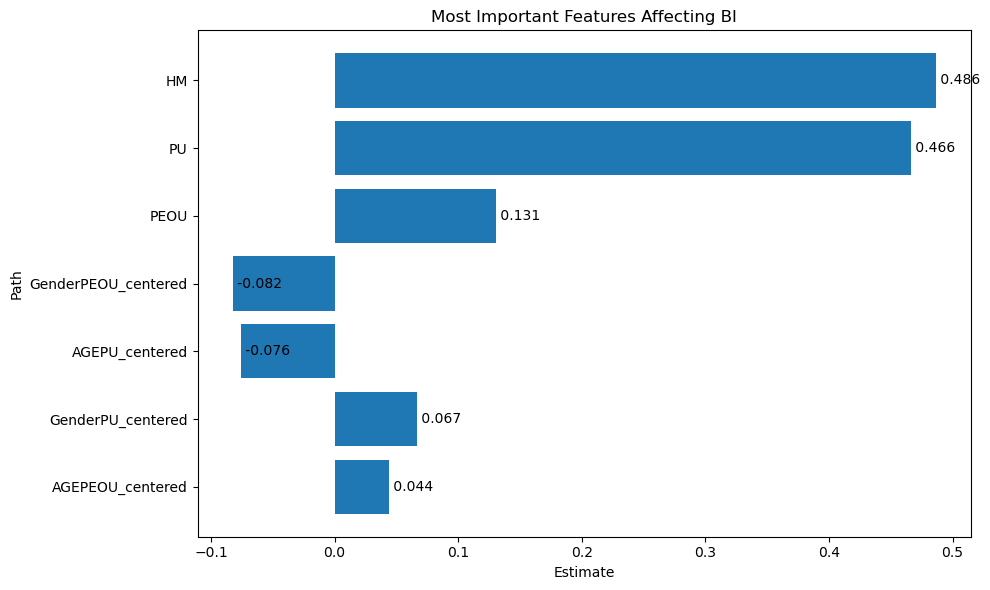


Total effects not available for this model.


In [70]:
import pandas as pd
import numpy as np
from semopy import Model, calc_stats
import matplotlib.pyplot as plt

# Define the model specification
model_spec = """
# Measurement model
PU =~ PU1 + PU2 + PU3 + PU4
PEOU =~ PE1 + PE2 + PE3
BI =~ BI1 + BI2 + BI3
PPV =~PPV1 + PPV2 + PPV3
SOI =~ SOI1+ SOI2 +SOI3 + SOI4
SEI =~ SEI1 + SEI2 + SEI3
HM =~ HM1 +HM2 + HM3
AT =~ AT1 + AT2 + AT3

# Structural model
PEOU ~  PPV + SOI + SEI + AGE_num + Gender_num
PU ~ HM + PPV + SOI + SEI + AGE_num + Gender_num
HM ~ PEOU
BI ~ AGEPEOU_centered
BI ~ GenderPEOU_centered
BI ~ AGEPU_centered
BI ~ GenderPU_centered
BI ~ PU
BI ~ PEOU
BI ~ HM
"""

# Create and fit the model
model = Model(model_spec)
res = model.fit(df_survey_cleaned)

# Get the parameter estimates
estimates = model.inspect()
print(f"estimates: {estimates}")

# Extract all path coefficients (structural relationships)
all_paths = estimates[estimates['op'] == '~'].copy()

print(f"all_paths: {all_paths}")

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Calculate and print fit statistics
fit_stats = calc_stats(model)
print("\nModel Fit Statistics:")
print(fit_stats)

# Convert 'Estimate' and 'Std. Err' to numeric, replacing non-numeric values with NaN
all_paths['Estimate'] = pd.to_numeric(all_paths['Estimate'], errors='coerce')
all_paths['Std. Err'] = pd.to_numeric(all_paths['Std. Err'], errors='coerce')

# Add absolute value of estimates for ranking
all_paths['Abs_Estimate'] = all_paths['Estimate'].abs()

# Rank paths based on absolute estimate
all_paths['Rank'] = all_paths['Abs_Estimate'].rank(ascending=False, method='dense')

# Sort by rank
all_paths = all_paths.sort_values('Rank')

# Reset index
all_paths = all_paths.reset_index(drop=True)

# Select relevant columns and rename for clarity
all_paths = all_paths[['lval', 'rval', 'Estimate', 'Std. Err', 'z-value', 'p-value', 'Rank']]
all_paths.columns = ['To', 'From', 'Estimate', 'Std_Err', 'z_value', 'p_value', 'Rank']

# Print all paths
print('*********************************************************************************************')
print("All Structural Paths:")
print(all_paths)

# R-squared values for endogenous variables
r_squared = estimates[estimates['op'] == '~~'].copy()
r_squared['R_squared'] = 1 - pd.to_numeric(r_squared['Estimate'], errors='coerce')
r_squared = r_squared[r_squared['lval'] == r_squared['rval']]  # Only keep diagonal elements
r_squared = r_squared[['lval', 'R_squared']]
r_squared.columns = ['Variable', 'R_squared']
print("\nR-squared values for endogenous variables:")
print(r_squared)

# Find the R-squared of BI
bi_r_squared = r_squared[r_squared['Variable'] == 'BI']['R_squared'].values

if len(bi_r_squared) > 0:
    bi_r_squared = bi_r_squared[0]
    # Create TAM_model_BI_R_squared dataframe
    TAM_model_BI_R_squared = pd.DataFrame({
        'model_name': ['TAM'],
        'BI_R_squared': [bi_r_squared],
        'run_type': ['Initial']
    })
    print("\nTAM_model_BI_R_squared:")
    print(TAM_model_BI_R_squared)
else:
    print("\nWarning: R-squared for BI not found in the DataFrame.")

# Extract only path coefficients related to BI
paths = [('BI', 'PU'), ('BI', 'PEOU'), ('BI', 'HM'), ('BI',  'AGEPU_centered'), ('BI',  'GenderPU_centered'), ('BI',  'AGEPEOU_centered'),('BI',  'GenderPEOU_centered'), ('BI','BI')]

# Create a list to store the important features
important_features = []

for path in paths:
    coef = estimates[(estimates['lval'] == path[0]) & 
                     (estimates['op'] == '~') & 
                     (estimates['rval'] == path[1])]
    if not coef.empty:
        feature = {
            'from': path[1],
            'to': path[0],
            'Estimate': coef['Estimate'].values[0],
            'Std_Err': coef['Std. Err'].values[0],
            'z-value': coef['z-value'].values[0],
            'p-value': coef['p-value'].values[0]
        }
        important_features.append(feature)

# Create TAM_BI_important_features dataframe
TAM_BI_important_features = pd.DataFrame(important_features)

# Add rank column based on absolute Estimate value
TAM_BI_important_features['rank'] = TAM_BI_important_features['Estimate'].abs().rank(ascending=False, method='dense')

# Sort by rank
TAM_BI_important_features = TAM_BI_important_features.sort_values('rank')

# Reset index
TAM_BI_important_features = TAM_BI_important_features.reset_index(drop=True)

# Print the results
print("TAM_BI_important_features:")
print(TAM_BI_important_features)

print("\nEffect Sizes (Standardized Estimates):")
standardized_estimates = estimates[estimates['op'] == '~'].copy()
standardized_estimates['Estimate'] = pd.to_numeric(standardized_estimates['Estimate'], errors='coerce')
standardized_estimates['Std_Err'] = pd.to_numeric(standardized_estimates['Std. Err'], errors='coerce')
standardized_estimates['Std_Estimate'] = standardized_estimates['Estimate'] / standardized_estimates['Std_Err']
standardized_estimates['Std_Estimate'] = standardized_estimates['Std_Estimate'].replace([np.inf, -np.inf], np.nan)
print(standardized_estimates[['lval', 'rval', 'Std_Estimate']])

# Plotting the most important features
plt.figure(figsize=(10, 6))
plt.barh(TAM_BI_important_features['from'], TAM_BI_important_features['Estimate'])
plt.xlabel('Estimate')
plt.ylabel('Path')
plt.title('Most Important Features Affecting BI')
plt.gca().invert_yaxis()  # Invert y-axis to show highest estimate at the top
for i, v in enumerate(TAM_BI_important_features['Estimate']):
    plt.text(v, i, f' {v:.3f}', va='center')
plt.tight_layout()
plt.show()

# Total effects (if available)
if hasattr(model, 'effects'):
    total_effects = model.effects()
    print("\nTotal Effects:")
    print(total_effects)
else:
    print("\nTotal effects not available for this model.")

In [58]:
corr_matrix = df_survey_cleaned[['PEOU_centered','PU_centered','PEOU_centered','HM_centered','SOI_centered','SEI_centered',
'PPV_centered','AGEPEOU_centered','AGEPU_centered','GenderPEOU_centered','GenderPU_centered','AGE_num','Gender_num']].corr()
corr_matrix

,PEOU_centered,PU_centered,PEOU_centered,HM_centered,SOI_centered,SEI_centered,PPV_centered,AGEPEOU_centered,AGEPU_centered,GenderPEOU_centered,GenderPU_centered,AGE_num,Gender_num
PEOU_centered,1.000000,0.842473,1.000000,0.717343,0.729172,0.758146,0.741169,0.903767,0.751901,0.782871,0.633598,0.106794,0.026399
PU_centered,0.842473,1.000000,0.842473,0.813721,0.720960,0.773222,0.814127,0.752889,0.897720,0.631648,0.781554,0.067839,0.068698
PEOU_centered,1.000000,0.842473,1.000000,0.717343,0.729172,0.758146,0.741169,0.903767,0.751901,0.782871,0.633598,0.106794,0.026399
HM_centered,0.717343,0.813721,0.717343,1.000000,0.734184,0.732694,0.844827,0.621928,0.710296,0.514012,0.620191,0.087772,0.039102
SOI_centered,0.729172,0.720960,0.729172,0.734184,1.000000,0.850025,0.757310,0.653873,0.646240,0.551810,0.557134,0.160776,0.089000
SEI_centered,0.758146,0.773222,0.758146,0.732694,0.850025,1.000000,0.782172,0.662771,0.671159,0.554455,0.564762,0.166399,0.076427
PPV_centered,0.741169,0.814127,0.741169,0.844827,0.757310,0.782172,1.000000,0.658734,0.728062,0.511383,0.612268,0.123541,0.067668
AGEPEOU_centered,0.903767,0.752889,0.903767,0.621928,0.653873,0.662771,0.658734,1.000000,0.831459,0.792041,0.650228,0.062064,-0.008735
AGEPU_centered,0.751901,0.897720,0.751901,0.710296,0.646240,0.671159,0.728062,0.831459,1.000000,0.648769,0.812774,0.027678,0.007854
GenderPEOU_centered,0.782871,0.631648,0.782871,0.514012,0.551810,0.554455,0.511383,0.792041,0.648769,1.000000,0.808892,0.047747,0.010262


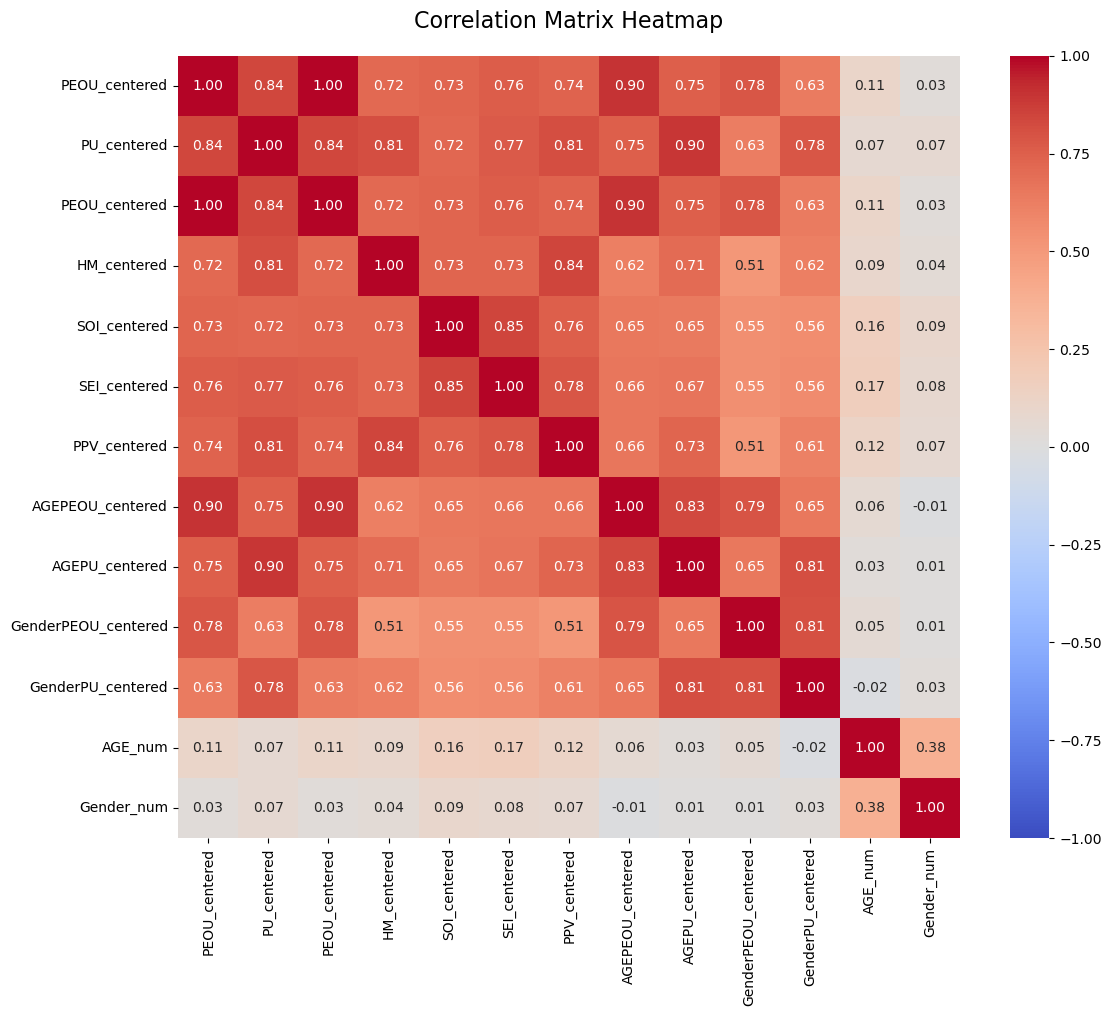

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming corr_matrix is your correlation matrix

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create the heatmap
heatmap = sns.heatmap(corr_matrix, 
                      annot=True,  # Add number annotations
                      cmap="coolwarm",  # Color scheme
                      vmin=-1, vmax=1,  # Fix the color scale from -1 to 1
                      center=0,  # Center the colormap at 0
                      square=True,  # Make sure the cells are square
                      fmt=".2f")  # Format annotations to 2 decimal places

# Set the title
plt.title("Correlation Matrix Heatmap", fontsize=16, pad=20)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Show the plot
plt.show()

In [28]:
### WIP To be able to Satisfy Hypothesis 3

### Original TAM - Davis 1989

In [ ]:
import pandas as pd
from semopy import Model

# Define the model specification
model_spec = """
 
# Measurement model
PU =~ PU1 + PU2 + PU3 + PU4
PEOU =~ PEOU1 + PEOU2 + PEOU3
 
BI =~ BI1 + BI2 + BI3

# Structural model
PEOU ~ AGEPEOU_centered + GenderPEOU_centered
PU ~ PEOU + AGEPU_centered + GenderPU_centered
BI ~ PU + PEOU
 
  
  
"""

# Create the model
model = Model(model_spec)


# Fit the model
res = model.fit(df_survey_cleaned)

# Get the parameter estimates
estimates = model.inspect()

# Find the variance of BI
bi_variance = estimates[estimates['lval'] == 'BI']['Estimate'].values[0]

print(f"Total variance of BI: {bi_variance}")

# Get the path coefficients
path_coefficients = model.inspect()

# Print all path coefficients
print(path_coefficients)

# Extract and print specific path coefficients
# Define the paths we're interested in
paths = [
    ('PU', 'AGE_num'), ('PU', 'Gender_num'), ('PU', 'HM'), ('PU', 'PE'), ('PU', 'PPV'), ('PU', 'SOI'), ('PU', 'SEI'),
    ('PEOU', 'AGE_num'), ('PEOU', 'Gender_num'), ('PEOU', 'HM'), ('PEOU', 'PE'), ('PEOU', 'PPV'), ('PEOU', 'SOI'), ('PEOU', 'SEI'),
    ('AT', 'PU'), ('AT', 'PEOU'),
    ('BI', 'AT'), ('BI', 'PU'), ('BI', 'PEOU'),
    ('HM', 'AGE_num'), ('HM', 'Gender_num'),
    ('PPV', 'AGE_num'), ('PPV', 'Gender_num'),
    ('SOI', 'AGE_num'), ('SOI', 'Gender_num'),
    ('SEI', 'AGE_num'), ('SEI', 'Gender_num'),
    ('PE', 'AGE_num'), ('PE', 'Gender_num')
]

# Extract and print specific path coefficients
print("Path Coefficients:")
for path in paths:
    coef = path_coefficients[(path_coefficients['lval'] == path[0]) & 
                             (path_coefficients['op'] == '~') & 
                             (path_coefficients['rval'] == path[1])]['Estimate']
    if not coef.empty:
        print(f"Path coefficient from {path[1]} to {path[0]}: {coef.values[0]}")
    else:
        print(f"Path coefficient from {path[1]} to {path[0]}: Not found")
# Get model fit indices
fit_indices = semopy.calc_stats(model)

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Display path coefficients
print("Path Coefficients:")
print(path_coefficients)
print("\n")

# Display model fit indices
print("Model Fit Indices:")
for index, value in fit_indices.items():
    if isinstance(value, float):
        print(f"{index}: {value:.6f}")
    else:
        print(f"{index}: {value}")

# Display specific fit indices if available
print("\nSpecific Fit Indices:")
if 'CFI' in fit_indices.index:
    print(f"CFI: {fit_indices['CFI']:.6f}")
if 'RMSEA' in fit_indices.index:
    print(f"RMSEA: {fit_indices['RMSEA']:.6f}")
if 'SRMR' in fit_indices.index:
    print(f"SRMR: {fit_indices['SRMR']:.6f}")

# Reset display options to default (optional)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

### Key take aways - possible non linear relations

### End of TAM